# 06 · Face model (separate from the Sign model)
Emotion from a ViT FER model on the face crop · non-manual cues from the 68 face landmarks relative to the signer's own baseline.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

ฉันปลอบเพื่อนร้องไห้ | emotion: neutral {'angry': 0.005, 'disgust': 0.002, 'fear': 0.003, 'happy': 0.006, 'neutral': 0.903, 'sad': 0.08, 'surprise': 0.001} | strongest non-neutral: {'emotion': 'sad', 'emotion_th': 'เศร้า', 'p': 0.08}
   NMM: {'brow_raise_tail': 1.0828485488891602, 'brow_furrow': 1.0351317167282104, 'mouth_open_frac': 0.007751937984496124, 'head_shake_cycles': 0, 'head_nod_cycles': 2, 'head_forward_tail': 0.05630183219909668, 'question_yesno': False, 'negation': False, 'affirmation': True}


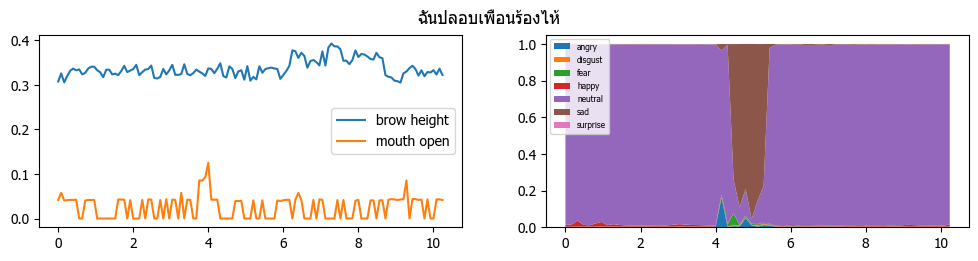

ไปทานข้าวด้วยกันมั้ย | emotion: neutral {'angry': 0.002, 'disgust': 0.002, 'fear': 0.044, 'happy': 0.117, 'neutral': 0.704, 'sad': 0.003, 'surprise': 0.126} | strongest non-neutral: {'emotion': 'surprise', 'emotion_th': 'ประหลาดใจ', 'p': 0.126}
   NMM: {'brow_raise_tail': -0.38280051946640015, 'brow_furrow': 0.7513621032238006, 'mouth_open_frac': 0.03571428571428571, 'head_shake_cycles': 0, 'head_nod_cycles': 2, 'head_forward_tail': 0.013559699058532715, 'question_yesno': False, 'negation': False, 'affirmation': True}


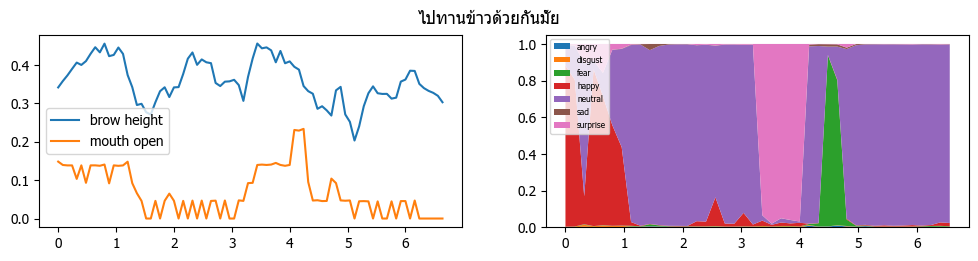

In [2]:
from modules.face_v4 import FaceModel, nmm, landmark_signals
from modules.data import decode_frames
fm = FaceModel()
for stem in ['ฉันปลอบเพื่อนร้องไห้', 'ไปทานข้าวด้วยกันมั้ย']:
    d = np.load(ART/'pose_v4'/f'test_{stem}_125.npz'); kp, sc, hw = d['kp'], d['sc'], tuple(d['hw'])
    fr = np.concatenate(list(decode_frames(ROOT/'data_test'/f'{stem}.mp4', fps=12.5)))
    emo = fm.emotions(fr, kp, sc); cues = nmm(kp, sc, hw)
    print(stem, '| emotion:', emo['emotion'], emo['probs'], '| strongest non-neutral:', emo['strongest_non_neutral'])
    print('   NMM:', cues)
    s = landmark_signals(kp, sc, hw); t = np.arange(len(kp))/12.5
    fig, ax = plt.subplots(1, 2, figsize=(12, 2.5)); ax[0].plot(t, s['brow'], label='brow height'); ax[0].plot(t, s['mouth'], label='mouth open'); ax[0].legend()
    pf = emo['per_frame']; ax[1].stackplot(np.array(emo['frames'])/12.5, pf.T, labels=['angry','disgust','fear','happy','neutral','sad','surprise']); ax[1].legend(fontsize=6, loc='upper left'); plt.suptitle(stem); plt.show()